In [11]:
import numpy as np
import matplotlib.pyplot as plt

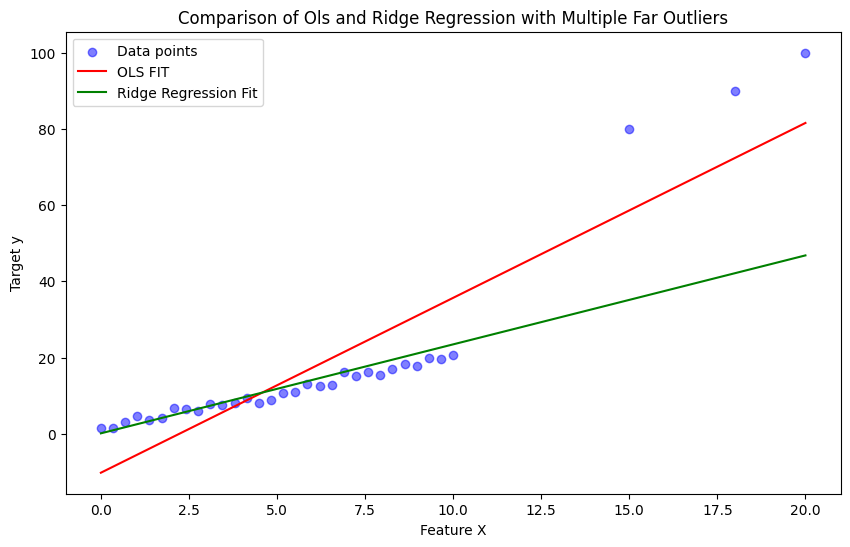

In [13]:
# set a random seed for reproductibility 
np.random.seed(42)

# Generate a simple linear dataset
n_samples=30
x_input=np.linspace(0,10,n_samples)
y=2*x_input+1+np.random.randn(n_samples) #True slope=2, intercept=1, some noise 

#Add three impactful outliers 
x_input=np.append(x_input,[15,18,20]) #farther o the x axis
y=np.append(y,[80,90,100]) #much higher y values 


#Add the intercept term 
X=np.hstack([np.ones((n_samples+3,1)),x_input.reshape(-1,1)])

#Compute the Ols and ridge regression solution 
beta_ols=np.linalg.inv(X.T@X)@X.T@y
lambda_ridge=1000  #A stronger lambda to emphasize ridges dampening effect 
I=np.eye(X.shape[1])
beta_Ridge=np.linalg.inv(X.T@X+lambda_ridge*I)@X.T@y


# Prepare to plot 
plt.figure (figsize=(10,6))
plt.scatter(x_input,y, color='blue', alpha=0.5, label='Data points')

#plot the Ols_fit
x_range=np.linspace(np.min(x_input), np.max(x_input),100)
y_ols=beta_ols[0]+beta_ols[1]*x_range
plt.plot(x_range,y_ols,'r-', label='OLS FIT')


#Plot the Ridge regression 
y_Ridge= beta_Ridge[0]+beta_Ridge[1]*x_range
plt.plot(x_range, y_Ridge, 'g-', label='Ridge Regression Fit')


plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.title('Comparison of Ols and Ridge Regression with Multiple Far Outliers')
plt.legend()
plt.show()